In [6]:
import torch
import torch.nn as nn
import math

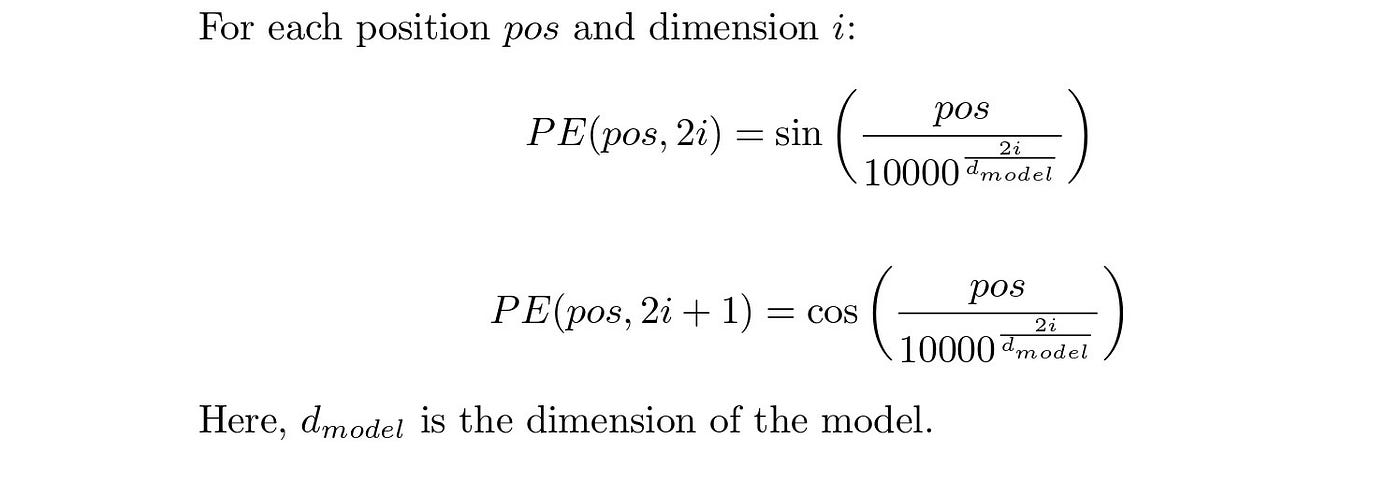

In [ ]:
class PositionaEncoding(nn.Module):
    def __init__(self, vocab_size, d_rpr, *args, **kwargs):
        super().__init__(*args, **kwargs)
        pe = torch.zeros(vocab_size, d_rpr)
        position = torch.arange(vocab_size).unsqueeze(1)
        denom = torch.exp(torch.arange(0, d_rpr, 2) * (-math.log(10000.0) / d_rpr))
        # print(position,denom, position * denom)
        pe[:,::2] = torch.sin(position * denom)
        pe[:,1::2] = torch.cos(position * denom)

        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)
        #  pe is stored as part of the module's state, but it's not treated as a trainable parameter during backpropagation.
        #  It's primarily used for tensors that are needed by the module but don't require gradient update
    def forward(self,x):
        x += self.pe[:, :x.size(1)]
        return x

a = PositionaEncoding(4,6)
a.forward(torch.rand((1,1,6)))


tensor([[[0.4955, 1.1141, 0.4634, 1.9808, 0.2203, 1.8484]]])

In [ ]:
class TransformerModel(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, d_rpr=512, nhead=8, num_layers = 6, d_ff = 2048 , dropout=0.1):
        super().__init__()
        self.d_rpr = d_rpr
        
        self.source_embedding = nn.Embedding(src_vocab_size, d_rpr)
        self.target_embedding = nn.Embedding(tgt_vocab_size, d_rpr)
        self.pos_encoder = PositionaEncoding(5000, d_rpr)

        self.transformer = nn.Transformer(
            d_model=d_rpr,
            nhead=nhead,
            num_encoder_layers=num_layers,
            num_decoder_layers=num_layers,
            dim_feedforward=d_ff,
            dropout=dropout,
            batch_first=True
        )
        self.fc_out = nn.Linear(d_rpr,tgt_vocab_size)


a = TransformerModel(src_vocab_size=10, tgt_vocab_size=5)
a.pos_encoder.pe

tensor([[[ 0.0000e+00,  1.0000e+00,  0.0000e+00,  ...,  1.0000e+00,
           0.0000e+00,  1.0000e+00],
         [ 8.4147e-01,  5.4030e-01,  8.2186e-01,  ...,  1.0000e+00,
           1.0366e-04,  1.0000e+00],
         [ 9.0930e-01, -4.1615e-01,  9.3641e-01,  ...,  1.0000e+00,
           2.0733e-04,  1.0000e+00],
         ...,
         [ 9.5625e-01, -2.9254e-01,  9.3594e-01,  ...,  8.5926e-01,
           4.9515e-01,  8.6881e-01],
         [ 2.7050e-01, -9.6272e-01,  8.2251e-01,  ...,  8.5920e-01,
           4.9524e-01,  8.6876e-01],
         [-6.6395e-01, -7.4778e-01,  1.4615e-03,  ...,  8.5915e-01,
           4.9533e-01,  8.6871e-01]]])

In [52]:
position

tensor([[0],
        [1],
        [2],
        [3]])

In [49]:
torch.sin(position * denom).T

tensor([[0.0000, 0.8415, 0.9093, 0.1411],
        [0.0000, 0.0100, 0.0200, 0.0300]])

In [53]:
pe

tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.]])

In [54]:
pe[:,0::2]

tensor([[0., 0.],
        [0., 0.]])

In [ ]:
v = 2
d = 4
pe = torch.zeros(v, d)
position = torch.arange(0,v).unsqueeze(1)
denom = torch.exp(torch.arange(0, d, 2) * (-math.log(10000.0) / d))
print(position * denom)
pe[:,0::2] = torch.sin(position * denom)
pe[:,1::2] = torch.cos(position * denom)


tensor([[0.0000, 0.0000],
        [1.0000, 0.0100]])


In [57]:
pe

tensor([[0.0000, 1.0000, 0.0000, 1.0000],
        [0.8415, 0.5403, 0.0100, 0.9999]])

In [34]:
denom

tensor([1.0000, 0.0022])

In [36]:
position * denom.unsqueeze(1).T

tensor([[0.0000, 0.0000],
        [1.0000, 0.0022],
        [2.0000, 0.0043]])